<a href="https://colab.research.google.com/github/Rachitsingh13/Student-Prediction/blob/w4/week4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   Age  Gender                         Stream  Internships  CGPA  Hostel  \
0   22    Male  Electronics And Communication            1     8       1   
1   21  Female               Computer Science            0     7       1   
2   22  Female         Information Technology            1     6       0   
3   21    Male         Information Technology            0     8       0   
4   22    Male                     Mechanical            0     8       1   

   HistoryOfBacklogs  PlacedOrNot  
0                  1            1  
1                  1            1  
2                  0            1  
3                  1            1  
4                  0            1  
(2966, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2966 entries, 0 to 2965
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                2966 non-null   int64 
 1   Gender             2966 non-null   object
 2   Stream            

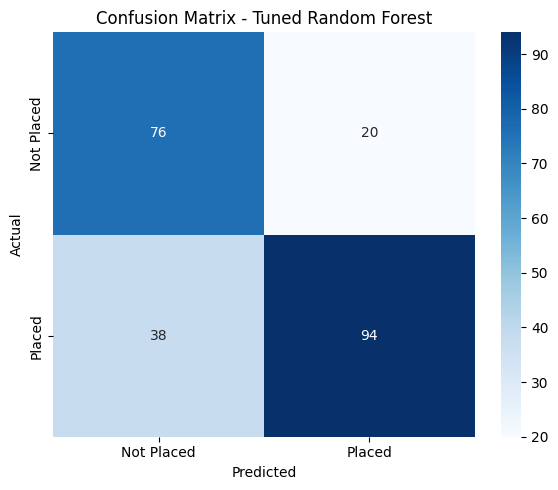

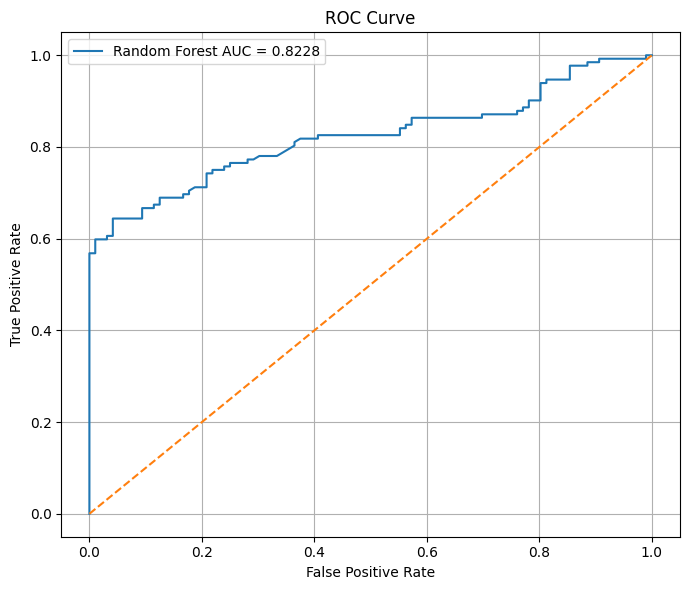

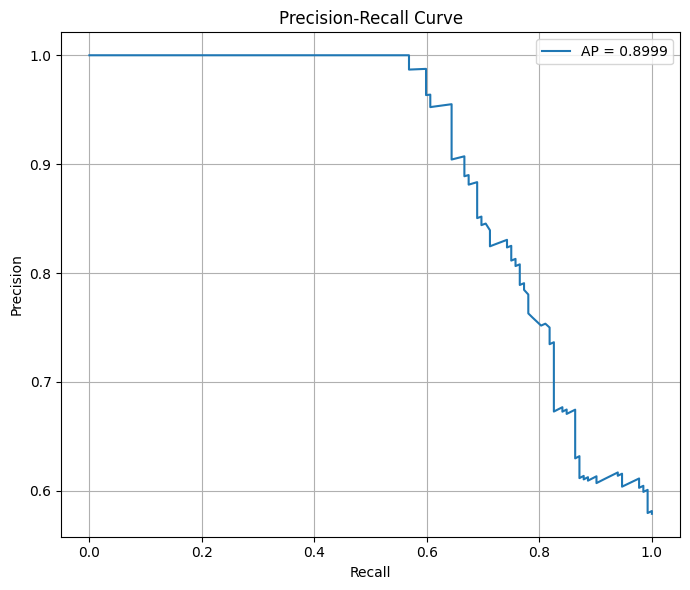


Bootstrap Reliability Analysis
      Metric    Mean  Lower 95%  Upper 95%
0   Accuracy  0.7464     0.6886     0.7982
1  Precision  0.8253     0.7476     0.8975
2     Recall  0.7126     0.6356     0.7879
3         F1  0.7640     0.7053     0.8197
4    ROC-AUC  0.8240     0.7673     0.8723


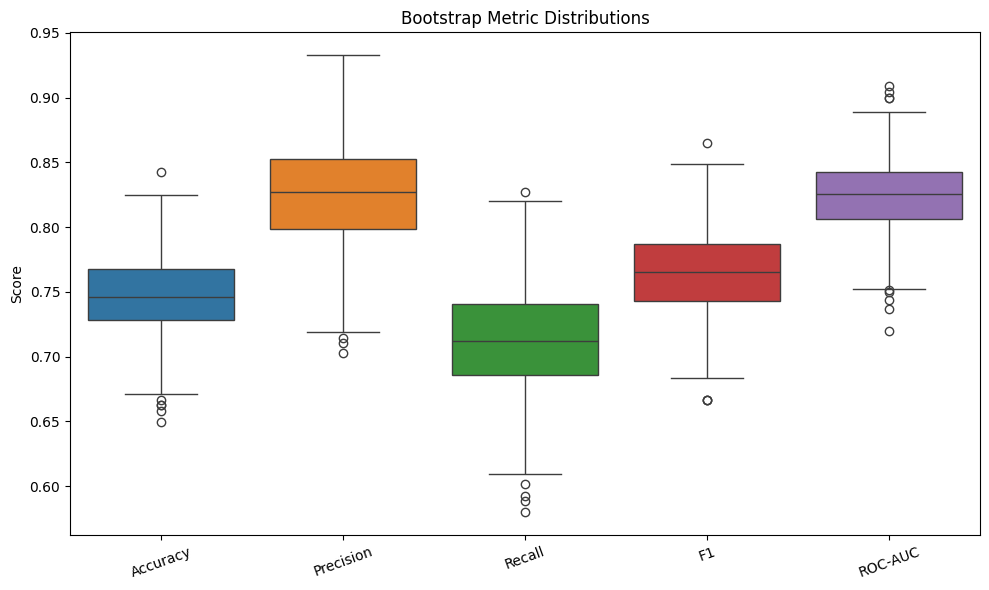


Permutation Feature Importance
             Feature  Importance     Std
4               CGPA      0.2072  0.0255
0                Age      0.0090  0.0202
3        Internships      0.0072  0.0110
6  HistoryOfBacklogs     -0.0011  0.0113
1             Gender     -0.0209  0.0074
5             Hostel     -0.0224  0.0074
2             Stream     -0.0301  0.0132


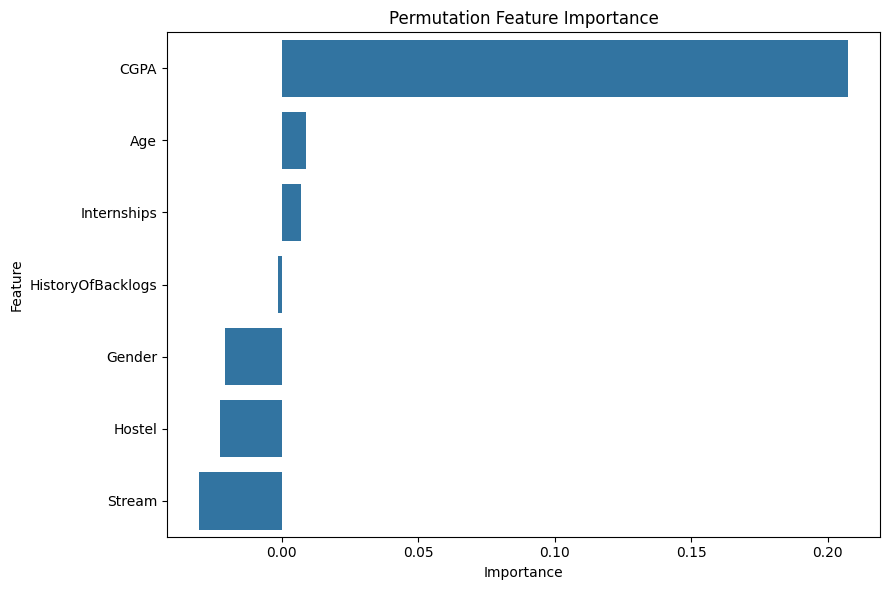

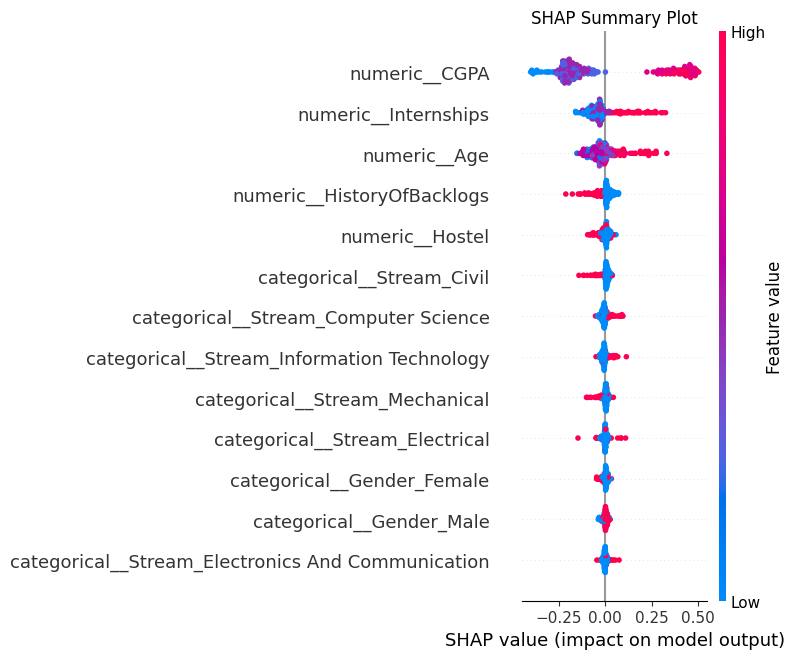

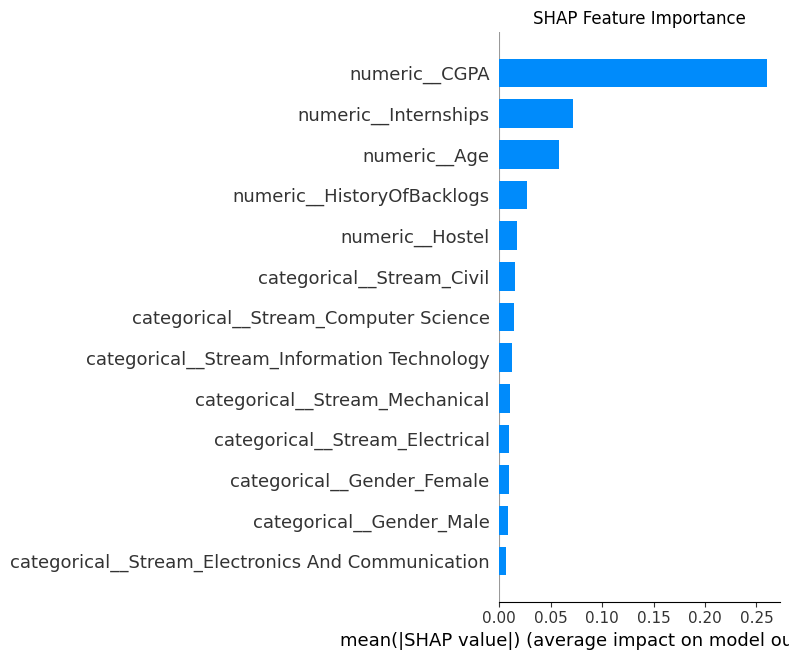


SHAP Feature Importance
                                              Feature  Mean_Absolute_SHAP
2                                       numeric__CGPA            0.259912
1                                numeric__Internships            0.071527
0                                        numeric__Age            0.058351
4                          numeric__HistoryOfBacklogs            0.026861
3                                     numeric__Hostel            0.017320
7                           categorical__Stream_Civil            0.015466
8                categorical__Stream_Computer Science            0.014243
11         categorical__Stream_Information Technology            0.012685
12                     categorical__Stream_Mechanical            0.010213
9                      categorical__Stream_Electrical            0.009481
5                          categorical__Gender_Female            0.009172
6                            categorical__Gender_Male            0.007983
10  categoric

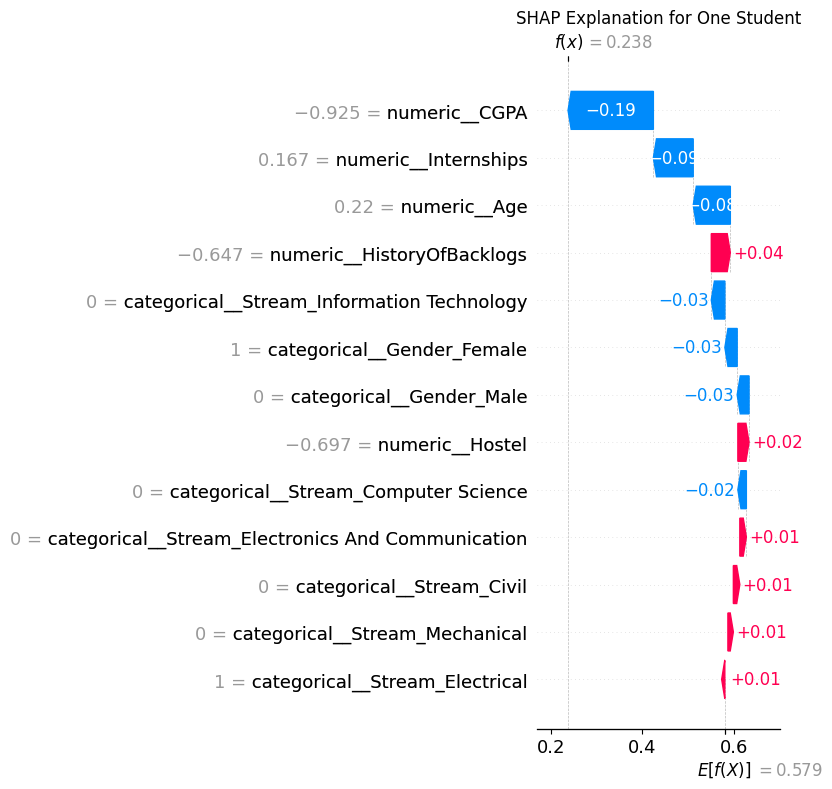


Individual Student Explanation
Student Data:
     Age  Gender      Stream  Internships  CGPA  Hostel  HistoryOfBacklogs
248   22  Female  Electrical            1     6       0                  0
Prediction: Not Placed
Placement Probability: 23.78 %

Out-of-Fold Validation
Accuracy: 0.7327
Precision: 0.7763
Recall: 0.7571
F1: 0.7666
ROC-AUC: 0.8208

False Positives
      Age  Gender                         Stream  Internships  CGPA  Hostel  \
608    21    Male         Information Technology            2     7       0   
1534   23    Male               Computer Science            0     7       0   
1863   24    Male                     Mechanical            1     7       1   
2083   19    Male               Computer Science            1     6       0   
832    22    Male  Electronics And Communication            3     7       0   
1510   23    Male  Electronics And Communication            0     7       0   
318    21  Female               Computer Science            0     6       1   


['week5_tuned_random_forest.pkl']

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_validate, cross_val_predict)
from sklearn.preprocessing import ( StandardScaler, OneHotEncoder)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

from sklearn.inspection import permutation_importance

FILE_PATH = "/content/collegePlace.csv"
df = pd.read_csv(FILE_PATH)
print(df.head())
print(df.shape)
print(df.info())
print(df.isnull().sum())
df = df.drop_duplicates()
df["PlacedOrNot"] = df["PlacedOrNot"].astype(int)
numeric_features = [
    "Age",
    "Internships",
    "CGPA",
    "Hostel",
    "HistoryOfBacklogs"
]
categorical_features = [
    "Gender",
    "Stream"
]
X = df.drop(columns=["PlacedOrNot"])
y = df["PlacedOrNot"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])
categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])
preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])
model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=15,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features="sqrt",
            random_state=42
        )
    )
])
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
cv_results = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    return_train_score=True,
    n_jobs=-1
)
cv_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Mean": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_roc_auc"].mean()
    ],
    "Std": [
        cv_results["test_accuracy"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std(),
        cv_results["test_roc_auc"].std()
    ]
})


print("\nCross Validation Results")
print(cv_summary.round(4))
model.fit(
    X_train,
    y_train
)


y_pred = model.predict(
    X_test
)


y_probability = model.predict_proba(
    X_test
)[:, 1]


accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

average_precision = average_precision_score(
    y_test,
    y_probability
)


print("\nTest Set Results")

print(
    "Accuracy:",
    round(accuracy, 4)
)

print(
    "Precision:",
    round(precision, 4)
)

print(
    "Recall:",
    round(recall, 4)
)

print(
    "F1 Score:",
    round(f1, 4)
)

print(
    "ROC-AUC:",
    round(roc_auc, 4)
)

print(
    "Average Precision:",
    round(average_precision, 4)
)


print("\nClassification Report")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Not Placed",
            "Placed"
        ],
        zero_division=0
    )
)


cm = confusion_matrix(
    y_test,
    y_pred
)


plt.figure(
    figsize=(6, 5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Not Placed",
        "Placed"
    ],
    yticklabels=[
        "Not Placed",
        "Placed"
    ]
)

plt.title(
    "Confusion Matrix - Tuned Random Forest"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.tight_layout()

plt.show()


fpr, tpr, _ = roc_curve(
    y_test,
    y_probability
)


plt.figure(
    figsize=(7, 6)
)

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve"
)

plt.legend()

plt.grid()

plt.tight_layout()

plt.show()


precision_values, recall_values, _ = precision_recall_curve(
    y_test,
    y_probability
)


plt.figure(
    figsize=(7, 6)
)

plt.plot(
    recall_values,
    precision_values,
    label=f"AP = {average_precision:.4f}"
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision-Recall Curve"
)

plt.legend()

plt.grid()

plt.tight_layout()

plt.show()


bootstrap_results = []

rng = np.random.RandomState(42)

n_bootstrap = 1000

for i in range(n_bootstrap):

    indices = rng.randint(
        0,
        len(y_test),
        len(y_test)
    )

    y_true_sample = y_test.iloc[
        indices
    ]

    y_pred_sample = y_pred[
        indices
    ]

    y_probability_sample = y_probability[
        indices
    ]

    bootstrap_results.append({

        "Accuracy": accuracy_score(
            y_true_sample,
            y_pred_sample
        ),

        "Precision": precision_score(
            y_true_sample,
            y_pred_sample,
            zero_division=0
        ),

        "Recall": recall_score(
            y_true_sample,
            y_pred_sample,
            zero_division=0
        ),

        "F1": f1_score(
            y_true_sample,
            y_pred_sample,
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_true_sample,
            y_probability_sample
        )
    })


bootstrap_df = pd.DataFrame(
    bootstrap_results
)


bootstrap_summary = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],

    "Mean": [
        bootstrap_df["Accuracy"].mean(),
        bootstrap_df["Precision"].mean(),
        bootstrap_df["Recall"].mean(),
        bootstrap_df["F1"].mean(),
        bootstrap_df["ROC-AUC"].mean()
    ],

    "Lower 95%": [
        bootstrap_df["Accuracy"].quantile(0.025),
        bootstrap_df["Precision"].quantile(0.025),
        bootstrap_df["Recall"].quantile(0.025),
        bootstrap_df["F1"].quantile(0.025),
        bootstrap_df["ROC-AUC"].quantile(0.025)
    ],

    "Upper 95%": [
        bootstrap_df["Accuracy"].quantile(0.975),
        bootstrap_df["Precision"].quantile(0.975),
        bootstrap_df["Recall"].quantile(0.975),
        bootstrap_df["F1"].quantile(0.975),
        bootstrap_df["ROC-AUC"].quantile(0.975)
    ]
})


print("\nBootstrap Reliability Analysis")

print(
    bootstrap_summary.round(4)
)


plt.figure(
    figsize=(10, 6)
)

sns.boxplot(
    data=bootstrap_df[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC-AUC"
        ]
    ]
)

plt.title(
    "Bootstrap Metric Distributions"
)

plt.ylabel(
    "Score"
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()


permutation = permutation_importance(
    model,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)


permutation_df = pd.DataFrame({

    "Feature":
    X_test.columns,

    "Importance":
    permutation.importances_mean,

    "Std":
    permutation.importances_std
})


permutation_df = permutation_df.sort_values(
    by="Importance",
    ascending=False
)


print("\nPermutation Feature Importance")

print(
    permutation_df.round(4)
)


plt.figure(
    figsize=(9, 6)
)

sns.barplot(
    data=permutation_df,
    x="Importance",
    y="Feature"
)

plt.title(
    "Permutation Feature Importance"
)

plt.tight_layout()

plt.show()


preprocessor_fitted = model.named_steps[
    "preprocessor"
]


classifier = model.named_steps[
    "classifier"
]


transformed_feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)


X_train_transformed = (
    preprocessor_fitted
    .transform(X_train)
)


X_test_transformed = (
    preprocessor_fitted
    .transform(X_test)
)


if hasattr(
    X_train_transformed,
    "toarray"
):

    X_train_transformed = (
        X_train_transformed.toarray()
    )

    X_test_transformed = (
        X_test_transformed.toarray()
    )


X_train_transformed_df = pd.DataFrame(
    X_train_transformed,
    columns=transformed_feature_names,
    index=X_train.index
)


X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=transformed_feature_names,
    index=X_test.index
)


explainer = shap.TreeExplainer(
    classifier
)


shap_values = explainer.shap_values(
    X_test_transformed_df
)


if isinstance(
    shap_values,
    list
):

    shap_positive = shap_values[1]

else:

    shap_positive = shap_values


if len(shap_positive.shape) == 3:

    shap_positive = shap_positive[:, :, 1]


shap.summary_plot(
    shap_positive,
    X_test_transformed_df,
    show=False
)

plt.title(
    "SHAP Summary Plot"
)

plt.tight_layout()

plt.show()


shap.summary_plot(
    shap_positive,
    X_test_transformed_df,
    plot_type="bar",
    show=False
)

plt.title(
    "SHAP Feature Importance"
)

plt.tight_layout()

plt.show()


mean_abs_shap = np.abs(
    shap_positive
).mean(axis=0)


shap_importance_df = pd.DataFrame({

    "Feature":
    transformed_feature_names,

    "Mean_Absolute_SHAP":
    mean_abs_shap
})


shap_importance_df = (
    shap_importance_df
    .sort_values(
        by="Mean_Absolute_SHAP",
        ascending=False
    )
)


print("\nSHAP Feature Importance")

print(
    shap_importance_df.head(15)
)


sample_index = 0


sample_explanation = shap.Explanation(

    values=shap_positive[sample_index],

    base_values=(
        explainer.expected_value[1]
        if isinstance(
            explainer.expected_value,
            np.ndarray
        )
        else explainer.expected_value
    ),

    data=X_test_transformed_df.iloc[
        sample_index
    ].values,

    feature_names=(
        transformed_feature_names
    )
)


shap.plots.waterfall(
    sample_explanation,
    max_display=15,
    show=False
)

plt.title(
    "SHAP Explanation for One Student"
)

plt.tight_layout()

plt.show()


sample_student = X_test.iloc[
    [sample_index]
]


sample_prediction = model.predict(
    sample_student
)[0]


sample_probability = model.predict_proba(
    sample_student
)[0][1]


print("\nIndividual Student Explanation")

print(
    "Student Data:"
)

print(
    sample_student
)


print(
    "Prediction:",
    "Placed"
    if sample_prediction == 1
    else "Not Placed"
)


print(
    "Placement Probability:",
    round(
        sample_probability * 100,
        2
    ),
    "%"
)


train_predictions = cross_val_predict(
    model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]


train_predicted_classes = (
    train_predictions >= 0.5
).astype(int)


cv_accuracy = accuracy_score(
    y_train,
    train_predicted_classes
)

cv_precision = precision_score(
    y_train,
    train_predicted_classes,
    zero_division=0
)

cv_recall = recall_score(
    y_train,
    train_predicted_classes,
    zero_division=0
)

cv_f1 = f1_score(
    y_train,
    train_predicted_classes,
    zero_division=0
)

cv_auc = roc_auc_score(
    y_train,
    train_predictions
)


print("\nOut-of-Fold Validation")

print(
    "Accuracy:",
    round(cv_accuracy, 4)
)

print(
    "Precision:",
    round(cv_precision, 4)
)

print(
    "Recall:",
    round(cv_recall, 4)
)

print(
    "F1:",
    round(cv_f1, 4)
)

print(
    "ROC-AUC:",
    round(cv_auc, 4)
)


error_analysis = X_test.copy()

error_analysis["Actual"] = y_test.values

error_analysis["Predicted"] = y_pred

error_analysis["Probability"] = y_probability

error_analysis["Error"] = (
    error_analysis["Actual"]
    !=
    error_analysis["Predicted"]
)


false_positives = error_analysis[
    (
        error_analysis["Actual"] == 0
    )
    &
    (
        error_analysis["Predicted"] == 1
    )
]


false_negatives = error_analysis[
    (
        error_analysis["Actual"] == 1
    )
    &
    (
        error_analysis["Predicted"] == 0
    )
]


print("\nFalse Positives")

print(
    false_positives
)


print("\nFalse Negatives")

print(
    false_negatives
)


final_results = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "Average Precision"
    ],

    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        average_precision
    ]
})


print("\nFinal Evaluation")

print(
    final_results.round(4)
)


cv_summary.to_csv(
    "week5_cross_validation_results.csv",
    index=False
)


bootstrap_summary.to_csv(
    "week5_bootstrap_results.csv",
    index=False
)


permutation_df.to_csv(
    "week5_permutation_importance.csv",
    index=False
)


shap_importance_df.to_csv(
    "week5_shap_importance.csv",
    index=False
)


final_results.to_csv(
    "week5_final_results.csv",
    index=False
)


false_positives.to_csv(
    "week5_false_positives.csv",
    index=False
)


false_negatives.to_csv(
    "week5_false_negatives.csv",
    index=False
)
joblib.dump(
    model,
    "week5_tuned_random_forest.pkl"
)